# 05 — Evaluate on Test Set

โหลด `best_model.pth` มาทดสอบบน **test set** ที่โมเดลไม่เคยเห็นเลย

เป้าหมาย:
- accuracy บน test set
- confusion matrix
- ดูตัวอย่างภาพที่ predict ผิด

## 1. Import และโหลดโมเดล

In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'ใช้ device: {device}')

# --- โมเดล (ต้องตรงกับ 04 ทุกอย่าง) ---
class CosGokClassifier(nn.Module):
    def __init__(self, num_classes=2, size_inner=128, droprate=0.2):
        super().__init__()
        backbone = models.mobilenet_v2(weights='IMAGENET1K_V1')
        for param in backbone.parameters():
            param.requires_grad = False
        self.features = backbone.features
        self.pool     = nn.AdaptiveAvgPool2d((1, 1))
        self.head     = nn.Sequential(
            nn.Linear(1280, size_inner),
            nn.ReLU(),
            nn.Dropout(droprate),
            nn.Linear(size_inner, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.head(x)

model = CosGokClassifier().to(device)
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()
print('โหลด best_model.pth เรียบร้อย')

ใช้ device: cuda
โหลด best_model.pth เรียบร้อย


## 2. Test DataLoader

In [2]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

test_dataset = ImageFolder('data/test', transform=test_transforms)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

CLASS_NAMES = test_dataset.classes  # ['cos', 'gok']
print(f'class mapping: {test_dataset.class_to_idx}')
print(f'test: {len(test_dataset)} ภาพ')

class mapping: {'cos': 0, 'gok': 1}
test: 468 ภาพ


## 3. Inference บน Test Set

In [3]:
all_preds  = []
all_labels = []
all_paths  = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# เก็บ path ทุกไฟล์ตามลำดับ ImageFolder
all_paths = [path for path, _ in test_dataset.samples]

test_acc = (all_preds == all_labels).mean()
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'ถูก {(all_preds == all_labels).sum()} / {len(all_labels)} ภาพ')

Test Accuracy: 1.0000 (100.00%)
ถูก 468 / 468 ภาพ


## 4. Classification Report และ Confusion Matrix

              precision    recall  f1-score   support

         cos       1.00      1.00      1.00       236
         gok       1.00      1.00      1.00       232

    accuracy                           1.00       468
   macro avg       1.00      1.00      1.00       468
weighted avg       1.00      1.00      1.00       468



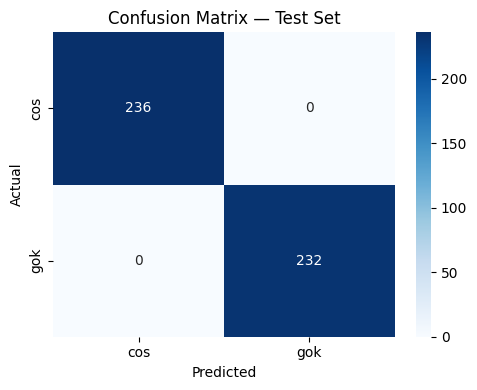

In [4]:
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

## 5. ดูภาพที่ Predict ผิด

In [5]:
from PIL import Image

wrong_idx = np.where(all_preds != all_labels)[0]
print(f'predict ผิด {len(wrong_idx)} ภาพ')

if len(wrong_idx) == 0:
    print('ไม่มีภาพที่ผิดเลย!')
else:
    n_show = min(12, len(wrong_idx))
    fig, axes = plt.subplots(2, n_show // 2 + n_show % 2, figsize=(16, 6))
    axes = axes.flatten()

    for i, idx in enumerate(wrong_idx[:n_show]):
        img = Image.open(all_paths[idx])
        axes[i].imshow(img)
        actual    = CLASS_NAMES[all_labels[idx]]
        predicted = CLASS_NAMES[all_preds[idx]]
        fname = all_paths[idx].split('\\')[-1]
        axes[i].set_title(f'actual: {actual}\npred: {predicted}\n{fname}', fontsize=7)
        axes[i].axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'ภาพที่ predict ผิด ({len(wrong_idx)} ภาพ)')
    plt.tight_layout()
    plt.show()

predict ผิด 0 ภาพ
ไม่มีภาพที่ผิดเลย!


In [ ]:
# ทดสอบ: ดู path ภาพจริงที่โมเดลใช้ predict
idx = 0  # เปลี่ยนเลขได้
print(f'path:   {all_paths[idx]}')
print(f'actual: {CLASS_NAMES[all_labels[idx]]}')
print(f'pred:   {CLASS_NAMES[all_preds[idx]]}')